# 🏭 바이브 코딩 실습 — 제조 공정 데이터 분석
## GitHub Codespaces + Copilot

> **목표**: AI에게 자연어로 요청해서 코드를 만들고, 직접 실행하면서 바이브 코딩을 경험하기

---

## 📋 실습 구성

| 실습 | 내용 | 핵심 경험 |
|------|------|-----------|
| **실습 1** | 엑셀 데이터 분석 + 시각화 | 데이터 불러오기, EDA, 차트 |
| **실습 2** | 머신러닝 모델 학습 | 분류 모델, 성능 평가 |


---



## ⚙️ 환경 설정

In [23]:
# 필요한 패키지 설치
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "openpyxl", "scikit-learn", "matplotlib",
                "seaborn", "pandas", "google-generativeai"], check=True)

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# matplotlib 폰트 설정 - 경고 메시지 억제
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# 나눔고딕이 없으므로 기본 폰트로 설정 (DejaVu 또는 시스템 폰트)
# 한글은 matplotlib에서 기본적으로 지원되지 않으나, 플롯에서는 영문 제목 사용
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

print("✅ 환경 설정 완료!")
print("📌 참고: 시스템 한글 폰트가 없어 기본 폰트를 사용합니다.")
print("   플롯 제목은 영문으로 표시되며, 데이터 분석은 정상 진행됩니다.")


✅ 환경 설정 완료!
📌 참고: 시스템 한글 폰트가 없어 기본 폰트를 사용합니다.
   플롯 제목은 영문으로 표시되며, 데이터 분석은 정상 진행됩니다.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


---
# 실습 1: 제조 공정 데이터 분석 + 시각화

**시나리오**: 스마트팩토리의 공정 데이터를 분석해서 불량 발생 패턴을 찾아냅니다.

**데이터 구조**:
| 컬럼 | 설명 | 정상 범위 |
|------|------|----------|
| 온도(°C) | 공정 온도 | 180 ~ 190°C |
| 압력(bar) | 공정 압력 | 5.5 ~ 6.5bar |
| 습도(%) | 작업장 습도 | 45 ~ 65% |
| 불량률(%) | 배치 불량률 | — |


### Step 1 — 데이터 로드

In [12]:
# 엑셀 파일 로드
# 실제 헤더 행이 두 번째 줄에 있으므로 header=1로 지정합니다.
df = pd.read_excel("manufacturing_quality_data.xlsx", sheet_name="공정데이터", header=1)

# 불량률(%) 컬럼이 문자열이나 '%' 기호로 들어올 수 있으므로 숫자로 정리합니다.
if "불량률(%)" in df.columns:
    df["불량률(%)"] = df["불량률(%)"].astype(str).str.replace("%", "", regex=False).str.strip()
    df["불량률(%)"] = pd.to_numeric(df["불량률(%)"], errors="coerce")
    if df["불량률(%)"].notna().any():
        if df["불량률(%)"].max() > 1:
            df["불량률(%)"] = df["불량률(%)"] / 100
    else:
        df["불량률(%)"] = df["불량수량"] / df["생산수량"]
        print("불량률(%) 값이 없어서 불량수량/생산수량으로 재계산했습니다.")
else:
    df["불량률(%)"] = df["불량수량"] / df["생산수량"]
    print("불량률(%) 컬럼이 없어 불량수량/생산수량으로 계산했습니다.")

print(f"📐 데이터 크기: {df.shape[0]}행 × {df.shape[1]}열")
print(f"\n📋 컬럼 목록:")
print(df.dtypes)
df.head(10)


불량률(%) 값이 없어서 불량수량/생산수량으로 재계산했습니다.
📐 데이터 크기: 200행 × 11열

📋 컬럼 목록:
배치ID           str
날짜             str
라인             str
제품코드           str
온도(°C)     float64
압력(bar)    float64
습도(%)      float64
작업자ID          str
생산수량         int64
불량수량         int64
불량률(%)     float64
dtype: object


,배치ID,날짜,라인,제품코드,온도(°C),압력(bar),습도(%),작업자ID,생산수량,불량수량,불량률(%)
0,B2024001,2024-03-18,L-03,PRD-A,191.3,6.06,57.7,W001,1885,137,0.072679
1,B2024002,2024-01-23,L-03,PRD-D,188.5,6.04,56.5,W005,1649,67,0.040631
2,B2024003,2024-03-14,L-02,PRD-B,178.9,6.13,66.5,W003,826,20,0.024213
3,B2024004,2024-02-20,L-02,PRD-B,187.9,6.83,62.8,W003,1235,30,0.024291
4,B2024005,2024-03-28,L-01,PRD-D,164.0,5.70,45.8,W003,1787,48,0.026861
5,B2024006,2024-01-28,L-03,PRD-B,184.3,5.85,56.1,W001,663,24,0.036199
6,B2024007,2024-02-23,L-02,PRD-C,170.5,6.27,59.9,W001,1872,49,0.026175
7,B2024008,2024-03-18,L-03,PRD-B,179.1,5.92,47.3,W002,1810,56,0.030939
8,B2024009,2024-02-09,L-03,PRD-C,192.6,5.28,55.3,W001,1146,94,0.082024
9,B2024010,2024-02-05,L-01,PRD-C,187.2,6.57,65.7,W002,792,21,0.026515


In [14]:
# 기본 통계 요약
df[["온도(°C)", "압력(bar)", "습도(%)", "생산수량", "불량수량", "불량률(%)"]].describe().round(3)


,온도(°C),압력(bar),습도(%),생산수량,불량수량,불량률(%)
count,200.000,200.000,200.000,200.000,200.000,200.000
mean,185.729,6.054,55.083,1287.115,48.860,0.038
std,7.864,0.481,10.276,421.685,31.017,0.019
min,164.000,4.830,23.500,502.000,0.000,0.000
25%,180.475,5.717,47.375,908.750,25.000,0.024
50%,185.700,6.110,55.000,1308.000,42.000,0.035
75%,191.300,6.360,61.800,1663.250,66.250,0.051
max,213.900,7.610,79.000,1997.000,143.000,0.093


---
### ✏️ 빈칸 1 — 직접 프롬프트를 작성해보세요!

> 💡 **업무**: 불량률이 높은 상위 10개의 조건 조합을 찾고 싶어요. 어떤 조건으로 정렬하면 될까요?

**LLM에게 아래 내용을 요청해보세요:**

```
(여기에 직접 프롬프트를 작성해보세요)
```

<details>
<summary>📎 예시 프롬프트 보기 (먼저 혼자 써본 후 확인하세요)</summary>

```
manufacturing_quality_data.xlsx 의 공정데이터 시트에서
불량률(%) 기준으로 내림차순 정렬해서 상위 10개 행을 보여주는 pandas 코드를 작성해줘.
결과에 배치ID, 라인, 온도, 압력, 습도, 불량률 컬럼만 포함해줘.
```

</details>

---

In [ ]:
# ✏️ 빈칸 1: 불량률(%) 기준으로 상위 10개 배치 조회
# 불량률(%) 기준으로 내림차순 정렬하여 상위 10개 행을 추출
top_10_defect = df.sort_values("불량률(%)", ascending=False).head(10)

# 지정된 컬럼만 표시
result = top_10_defect[["배치ID", "라인", "온도(°C)", "압력(bar)", "습도(%)", "불량률(%)"]]
print("🔝 불량률이 높은 상위 10개 배치")
print("=" * 80)
result


🔝 불량률이 높은 상위 10개 배치


,배치ID,라인,온도(°C),압력(bar),습도(%),불량률(%)
60,B2024061,L-03,194.7,5.05,67.3,0.093415
115,B2024116,L-03,193.3,4.93,60.7,0.083485
8,B2024009,L-03,192.6,5.28,55.3,0.082024
41,B2024042,L-02,191.9,5.09,57.5,0.081307
16,B2024017,L-03,192.9,6.30,70.3,0.080581
167,B2024168,L-01,190.5,6.04,69.0,0.080183
111,B2024112,L-02,192.5,6.10,69.9,0.077844
12,B2024013,L-03,200.6,5.82,70.9,0.075422
189,B2024190,L-03,186.8,5.08,79.0,0.074380
152,B2024153,L-03,197.2,6.19,67.2,0.074371


### Step 2 — 탐색적 데이터 분석 (EDA)

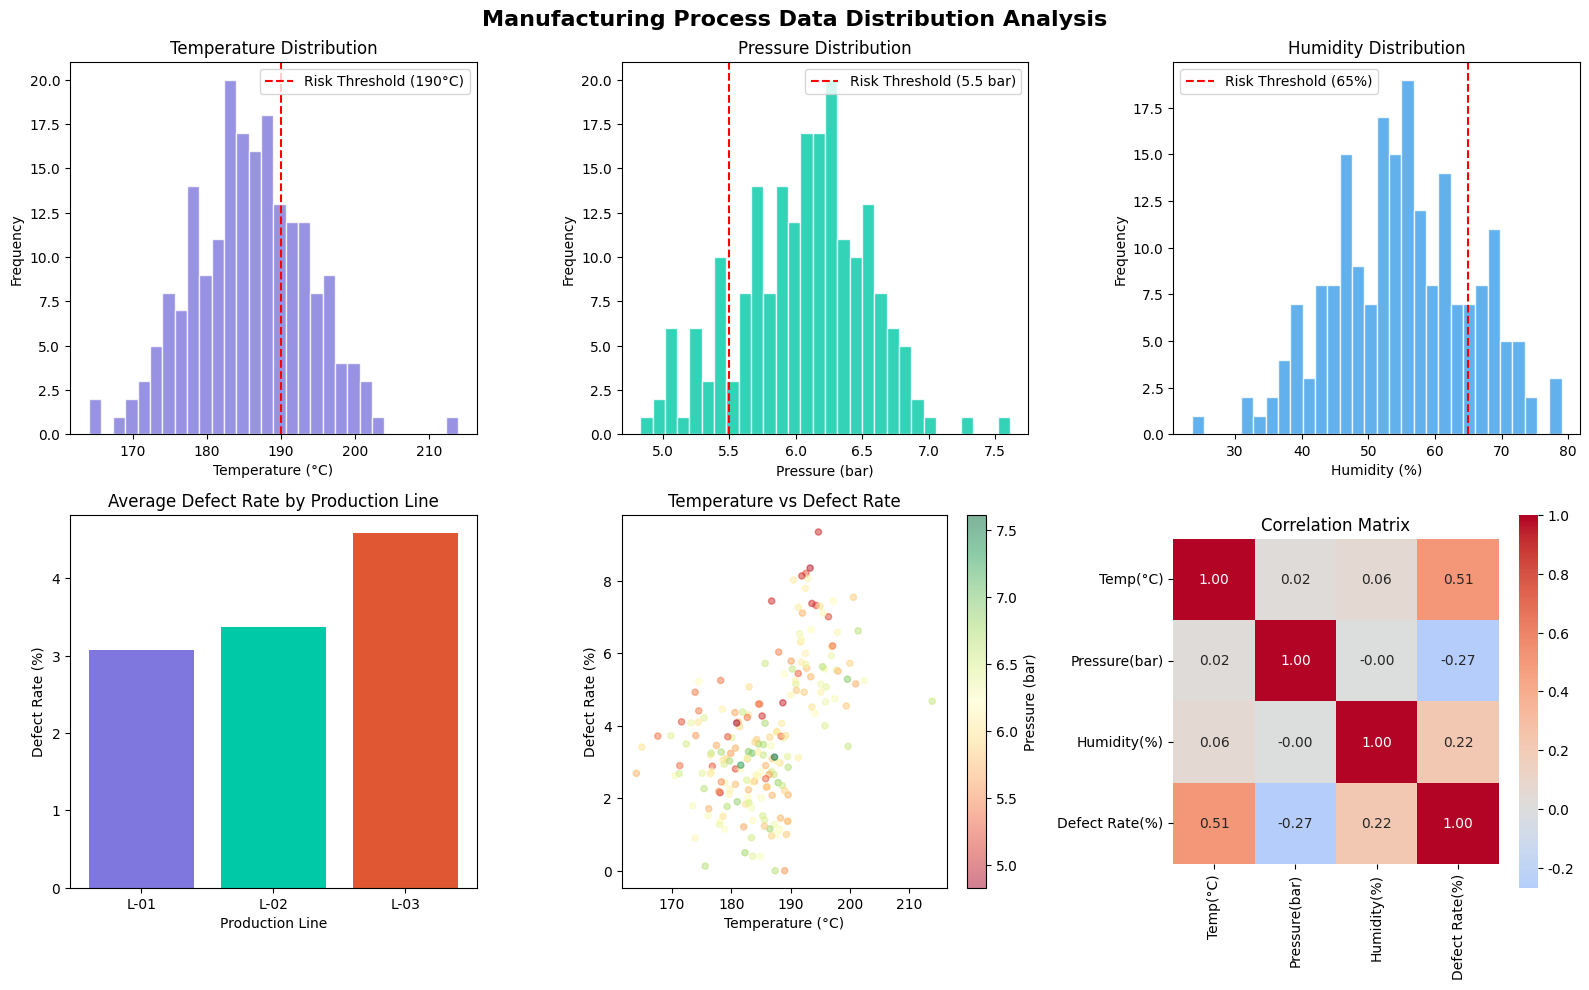

✅ EDA Complete! What patterns do you observe?


In [30]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Manufacturing Process Data Distribution Analysis", fontsize=16, fontweight="bold")

# 온도 분포
axes[0,0].hist(df["온도(°C)"], bins=30, color="#7F77DD", alpha=0.8, edgecolor="white")
axes[0,0].axvline(190, color="red", linestyle="--", label="Risk Threshold (190°C)")
axes[0,0].set_title("Temperature Distribution")
axes[0,0].set_xlabel("Temperature (°C)"); axes[0,0].set_ylabel("Frequency")
axes[0,0].legend()

# 압력 분포
axes[0,1].hist(df["압력(bar)"], bins=30, color="#00C9A7", alpha=0.8, edgecolor="white")
axes[0,1].axvline(5.5, color="red", linestyle="--", label="Risk Threshold (5.5 bar)")
axes[0,1].set_title("Pressure Distribution")
axes[0,1].set_xlabel("Pressure (bar)"); axes[0,1].set_ylabel("Frequency")
axes[0,1].legend()

# 습도 분포
axes[0,2].hist(df["습도(%)"], bins=30, color="#3B9EE8", alpha=0.8, edgecolor="white")
axes[0,2].axvline(65, color="red", linestyle="--", label="Risk Threshold (65%)")
axes[0,2].set_title("Humidity Distribution")
axes[0,2].set_xlabel("Humidity (%)"); axes[0,2].set_ylabel("Frequency")
axes[0,2].legend()

# 라인별 불량률
line_defect = df.groupby("라인")["불량률(%)"].mean() * 100
axes[1,0].bar(line_defect.index, line_defect.values, color=["#7F77DD","#00C9A7","#DF5833"])
axes[1,0].set_title("Average Defect Rate by Production Line")
axes[1,0].set_xlabel("Production Line"); axes[1,0].set_ylabel("Defect Rate (%)")

# 온도 vs 불량률
sc = axes[1,1].scatter(df["온도(°C)"], df["불량률(%)"]*100,
                       c=df["압력(bar)"], cmap="RdYlGn", alpha=0.5, s=20)
cbar = plt.colorbar(sc, ax=axes[1,1])
cbar.set_label("Pressure (bar)")
axes[1,1].set_title("Temperature vs Defect Rate")
axes[1,1].set_xlabel("Temperature (°C)"); axes[1,1].set_ylabel("Defect Rate (%)")

# 상관관계 히트맵
corr = df[["온도(°C)","압력(bar)","습도(%)","불량률(%)"]].corr()
sns.heatmap(corr, ax=axes[1,2], annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            xticklabels=["Temp(°C)", "Pressure(bar)", "Humidity(%)", "Defect Rate(%)"],
            yticklabels=["Temp(°C)", "Pressure(bar)", "Humidity(%)", "Defect Rate(%)"])
axes[1,2].set_title("Correlation Matrix")

plt.tight_layout(); plt.show()
print("✅ EDA Complete! What patterns do you observe?")


---
### ✏️ 빈칸 2 — 직접 프롬프트를 작성해보세요!

> 💡 **업무**: 라인별로 불량률이 다른 것 같아요. 제품코드별로도 불량률 차이가 있는지 박스플롯으로 확인하고 싶어요.

**LLM에게 아래 내용을 요청해보세요:**

```
(여기에 직접 프롬프트를 작성해보세요)
```

<details>
<summary>📎 예시 프롬프트 보기 (먼저 혼자 써본 후 확인하세요)</summary>

```
pandas와 matplotlib/seaborn을 사용해서
제품코드별 불량률(%) 분포를 박스플롯(boxplot)으로 시각화하는 코드를 작성해줘.
각 제품코드별 평균 불량률도 빨간 점으로 표시해줘.
데이터프레임 변수명은 df야.
```

</details>

---

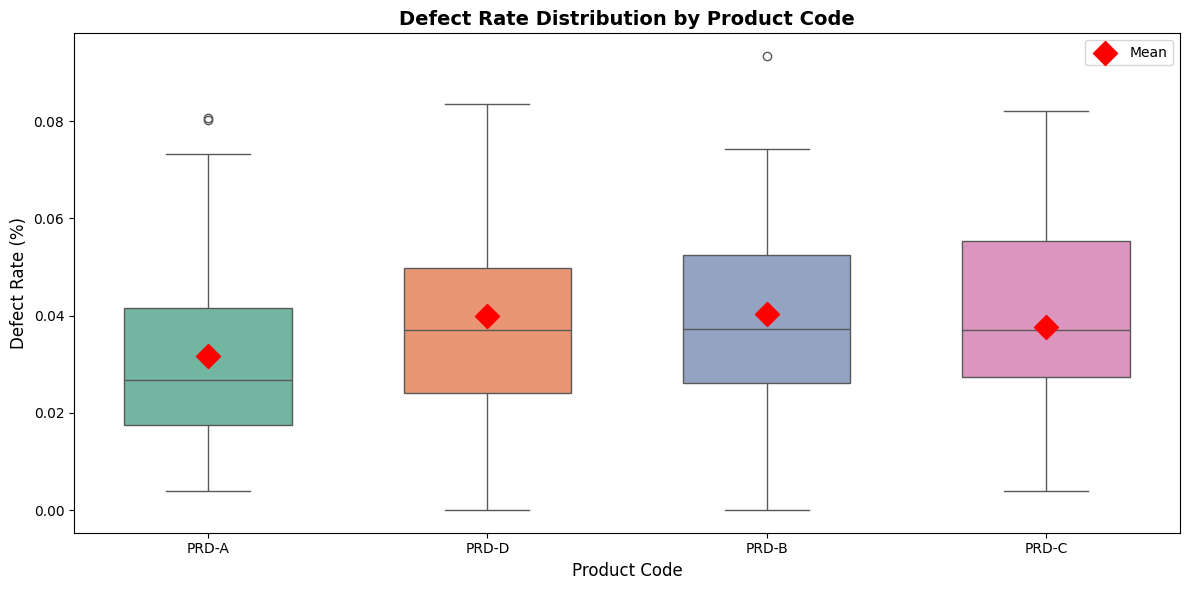


📊 Defect Rate Statistics by Product Code:
       count    mean     std    min     25%     50%     75%     max
제품코드                                                               
PRD-A   47.0  0.0317  0.0199  0.004  0.0175  0.0268  0.0415  0.0806
PRD-B   47.0  0.0399  0.0181  0.000  0.0262  0.0372  0.0525  0.0934
PRD-C   54.0  0.0403  0.0187  0.004  0.0273  0.0371  0.0553  0.0820
PRD-D   52.0  0.0376  0.0198  0.000  0.0241  0.0369  0.0498  0.0835


In [ ]:
# ✏️ 빈칸 2: 제품코드별 불량률 분포 박스플롯
fig, ax = plt.subplots(figsize=(12, 6))

# 제품코드별 불량률 boxplot
sns.boxplot(data=df, x="제품코드", y="불량률(%)", ax=ax, palette="Set2", width=0.6)

# 각 제품코드별 평균 불량률을 빨간 점으로 표시
means = df.groupby("제품코드")["불량률(%)"].mean()
positions = range(len(means))
ax.scatter(positions, means.values, color='red', s=150, zorder=3, label='Mean', marker='D')

ax.set_title("Defect Rate Distribution by Product Code", fontsize=14, fontweight='bold')
ax.set_xlabel("Product Code", fontsize=12)
ax.set_ylabel("Defect Rate (%)", fontsize=12)
ax.legend()

plt.tight_layout()
plt.show()

# 통계 요약
print("\n📊 Defect Rate Statistics by Product Code:")
print(df.groupby("제품코드")["불량률(%)"].describe().round(4))



---
### ✏️ 빈칸 3 — 직접 프롬프트를 작성해보세요!

> 💡 **업무**: 온도가 190도 초과, 압력이 5.5bar 미만, 습도가 65% 초과인 '위험 조건'만 따로 뽑고 싶어요.

**LLM에게 아래 내용을 요청해보세요:**

```
(여기에 직접 프롬프트를 작성해보세요)
```

<details>
<summary>📎 예시 프롬프트 보기 (먼저 혼자 써본 후 확인하세요)</summary>

```
df 데이터프레임에서 아래 조건을 모두 만족하는 행만 필터링해줘:
- 온도(°C) > 190
- 압력(bar) < 5.5
- 습도(%) > 65

필터링된 결과를 df_danger 변수에 저장하고,
몇 개 배치가 해당되는지 출력한 후 상위 5개를 보여줘.
```

</details>

---

In [ ]:
# ✏️ 빈칸 3: 위험 조건 배치 필터링
# 조건: 온도 > 190, 압력 < 5.5, 습도 > 65
df_danger = df[(df["온도(°C)"] > 190) & (df["압력(bar)"] < 5.5) & (df["습도(%)"] > 65)]

print("⚠️ RISK ALERT: 위험 조건 배치 현황")
print("=" * 80)
print(f"조건 (온도 > 190°C AND 압력 < 5.5bar AND 습도 > 65%)")
print(f"해당되는 배치 수: {len(df_danger)}개\n")

# 상위 5개 표시
if len(df_danger) > 0:
    display_cols = ["배치ID", "라인", "온도(°C)", "압력(bar)", "습도(%)", "불량률(%)", "불량수량"]
    print("Top 5 Dangerous Batches:")
    print(df_danger[display_cols].head(5))
else:
    print("위험 조건에 해당하는 배치가 없습니다.")

print("\n" + "=" * 80)

---
# 실습 2: 머신러닝 모델 학습

**목표**: 온도, 압력, 습도 등의 공정 데이터로 불량 여부를 예측하는 모델을 만듭니다.



### Step 1 — 데이터 전처리

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 타겟 변수 생성: 불량률 5% 초과 = 불량
df["불량여부"] = (df["불량률(%)"] > 0.05).astype(int)
print(f"✅ 불량 배치: {df['불량여부'].sum()}건")
print(f"✅ 정상 배치: {(df['불량여부']==0).sum()}건")

# 범주형 변수 인코딩
le_line   = LabelEncoder(); le_prod = LabelEncoder(); le_worker = LabelEncoder()
df["라인_enc"]    = le_line.fit_transform(df["라인"])
df["제품코드_enc"] = le_prod.fit_transform(df["제품코드"])
df["작업자ID_enc"] = le_worker.fit_transform(df["작업자ID"])

features = ["온도(°C)","압력(bar)","습도(%)","생산수량","라인_enc","제품코드_enc","작업자ID_enc"]
X = df[features]; y = df["불량여부"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\n📐 학습: {len(X_train)}개 / 테스트: {len(X_test)}개")


---
### ✏️ 빈칸 4 — 직접 프롬프트를 작성해보세요!

> 💡 **업무**: Random Forest 모델을 학습시키고 성능을 평가하고 싶어요. classification_report와 AUC-ROC 점수를 보고 싶어요.

**LLM에게 아래 내용을 요청해보세요:**

```
(여기에 직접 프롬프트를 작성해보세요)
```

<details>
<summary>📎 예시 프롬프트 보기 (먼저 혼자 써본 후 확인하세요)</summary>

```
scikit-learn의 RandomForestClassifier를 사용해서 불량 예측 모델을 학습하고 평가하는 코드를 작성해줘.

사용할 변수:
- X_train, X_test: 학습/테스트 특성
- y_train, y_test: 학습/테스트 타겟

포함할 내용:
1. RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced') 로 학습
2. classification_report 출력 (target_names=['정상','불량'])
3. AUC-ROC 점수 출력
```

</details>

---

In [ ]:
# ✏️ 빈칸 4: LLM이 작성한 코드를 여기에 붙여넣고 실행하세요

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# RandomForestClassifier 모델 생성 및 학습
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# 테스트 데이터에 대한 예측
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print('✅ Random Forest 학습 완료')
print('[Classification Report]')
print(classification_report(y_test, y_pred, target_names=['정상','불량']))

auc_score = roc_auc_score(y_test, y_prob)
print(f'AUC-ROC score: {auc_score:.4f}')

# 모델 객체를 다른 셀에서 다시 사용할 수 있도록 저장
rf_model = model




---
### ✏️ 빈칸 5 — 직접 프롬프트를 작성해보세요!

> 💡 **업무**: 어떤 변수가 불량 예측에 가장 중요한지 막대 차트로 보고 싶어요. 모델 학습이 완료된 후 실행하세요.

**LLM에게 아래 내용을 요청해보세요:**

```
(여기에 직접 프롬프트를 작성해보세요)
```

<details>
<summary>📎 예시 프롬프트 보기 (먼저 혼자 써본 후 확인하세요)</summary>

```
scikit-learn RandomForestClassifier의 feature_importances_를 활용해서
특성 중요도를 가로 막대 차트(barh)로 시각화하는 코드를 작성해줘.

조건:
- 중요도 높은 순서로 정렬
- 색상은 #7F77DD 사용
- 제목: '특성 중요도 (Feature Importance)'
- 변수명: model (학습된 모델), features (특성 이름 리스트)
```

</details>

---

In [ ]:
# ✏️ 빈칸 5: LLM이 작성한 코드를 여기에 붙여넣고 실행하세요

import pandas as pd
import matplotlib.pyplot as plt

# 모델 입력 특성 이름과 그래프 표시용 영어 이름 정의
features = ['온도(°C)', '압력(bar)', '습도(%)', '생산수량', '라인_enc', '제품코드_enc', '작업자ID_enc']
display_names = ['Temperature (°C)', 'Pressure (bar)', 'Humidity (%)', 'Production Quantity', 'Line Enc', 'Product Code Enc', 'Worker ID Enc']
feature_importances = pd.Series(model.feature_importances_, index=display_names)
feature_importances = feature_importances.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feature_importances.plot(kind='barh', color='#7F77DD')
plt.title('Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print('✅ Feature importance plot complete.')




